# Data Curation & Management – Final Exam
**Semester:** Spring 2025  **Generated:** 2025‑04‑23 17:22

**Student name:** Mahima Ullah

Complete each question in the order given. **Do not delete** any rubric headers marked with 💯 — they are used for grading.
Place any additional code or markdown cells *below* the relevant header.

### Final Project Requirements:
1. The code must run - if any part of the code throws an error, the final will receive a zero grade
2. The code must run in order.  At no time will the kernal need to be restarted or will the grader be required to "go backwards to go forwards".
    3. The grader will select Kernel>Restart Kernel and run all cells.  There should be no reason for that to cause an error
    4. Exception: The grader will have to adjust for the reference to the Kagglehub file only
3. Quality of work is paramount.  Simple results and basic findings will not receive an A.  In other words, the more inspection of the data, the better the grade.


# Final Project Data Selection:

You are now tasked with taking all that you have learned and applying it to a dataset.  For your final project, you will take on the role of a data analyst.  You are tasked with providing data insights and findings based on one of the four data sets found from Kagglehub.

*Note: You can only use one of these four datasets:*

* <a href='https://www.kaggle.com/datasets/bhargavchirumamilla/netflix-movies-and-tv-shows-till-2025'>Netflix Movies & TV Shows (till 2025) </a>
* <a href='https://www.kaggle.com/datasets/apoorvaappz/global-super-store-dataset'>Global Superstore</a>
* <a href='https://www.kaggle.com/datasets/ajaypalsinghlo/world-happiness-report-2024'>World Happiness Report 2024</a>
* <a href='https://www.kaggle.com/datasets/gitadityamaddali/flipkart-laptop-reviews'>Flipkart/Laptop Reviews (sentiment)</a>

The final project is not just about good code.  Its about using your data analytical mindset to uncover and present findings.  Therefore, basic descriptive statistics and simple aggregations will not suffice.  You are expected to inspect the data, ask probing questions of it, and then present the results, both visually and in a table-based output.

# Q0 Imports

Imports are started here.  If you are using other imports, make sure to include them in the code block below.

In [1]:
# Core data wrangling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text / sentiment analysis (if the dataset has free-text fields)
from textblob import TextBlob

# SQLite persistence
import sqlite3
from sqlalchemy import create_engine, text

# Dataset download via KaggleHub
import kagglehub

# File-system convenience (optional but handy)
from pathlib import Path


## Q1  Dataset selection 💯 (10 pts)

Dataset: World Happiness Report 2024 — https://www.kaggle.com/datasets/ajaypalsinghlo/world-happiness-report-2024

The three columns I anticipate using most are `Ladder_score` (the core happiness measure), `GDP_factor`, and `Corruption_factor`, as they capture economic output and governance quality as two of the most theoretically important drivers of wellbeing. I chose this dataset because it spans 143 countries and decomposes happiness into six quantified contributing factors, making it ideal for asking *which* drivers matter most and *where* the model breaks down. The dataset supports at least three substantive findings: (1) ranking the six happiness factors by their explanatory power across all countries, (2) identifying nations that score far above what their economic output would predict — and which factors explain that gap, and (3) showing that among equally wealthy nations, corruption perception creates a measurable happiness divide. Its structure is clean, consistently measured, and its findings are immediately relevant to questions of public policy and governance.

## Q2  ETL pipeline 💯 (25 pts)

Follow the sub‑sections below. Each must run top‑to‑bottom on a fresh kernel. After `Kernel ▸ Restart & Run All` the notebook must complete without manual intervention (except editing the DATA_PATH cell above).


### 2a Extract

In [2]:
path = kagglehub.dataset_download("ajaypalsinghlo/world-happiness-report-2024")

print("Path to dataset files:", path)

Path to dataset files: /Users/mahima/.cache/kagglehub/datasets/ajaypalsinghlo/world-happiness-report-2024/versions/1


In [3]:
data_dir = Path(path)
csv_file = next(data_dir.glob("*.csv"))
df_raw = pd.read_csv(csv_file)
print(f"Loaded: {csv_file.name}  |  Shape: {df_raw.shape}")
df_raw.head()

Loaded: WHR2024.csv  |  Shape: (143, 11)


,Country name,Ladder score,upperwhisker,lowerwhisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,7.741,7.815,7.667,1.844,1.572,0.695,0.859,0.142,0.546,2.082
1,Denmark,7.583,7.665,7.500,1.908,1.520,0.699,0.823,0.204,0.548,1.881
2,Iceland,7.525,7.618,7.433,1.881,1.617,0.718,0.819,0.258,0.182,2.050
3,Sweden,7.344,7.422,7.267,1.878,1.501,0.724,0.838,0.221,0.524,1.658
4,Israel,7.341,7.405,7.277,1.803,1.513,0.740,0.641,0.153,0.193,2.298


### 2b Transform – cleaning & feature engineering

In [4]:
# Typical tasks: .dropna(), .astype(), explode(), new columns, aggregations
df = df_raw.copy()

# Standardise column names
df.columns = df.columns.str.strip().str.replace(' ', '_')

# Drop rows missing the core score
df.dropna(subset=['Ladder_score'], inplace=True)
df.drop_duplicates(inplace=True)

# Rename factor columns for convenience
df.rename(columns={
    'Explained_by:_Log_GDP_per_capita':          'GDP_factor',
    'Explained_by:_Social_support':              'Social_support',
    'Explained_by:_Healthy_life_expectancy':     'Health_factor',
    'Explained_by:_Freedom_to_make_life_choices':'Freedom_factor',
    'Explained_by:_Generosity':                  'Generosity',
    'Explained_by:_Perceptions_of_corruption':   'Corruption_factor'
}, inplace=True)

num_cols = ['Ladder_score','GDP_factor','Social_support',
            'Health_factor','Freedom_factor','Generosity','Corruption_factor']

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.dropna(subset=num_cols, inplace=True)

# Feature engineering 1: happiness tier
df['happiness_tier'] = pd.cut(
    df['Ladder_score'],
    bins=[0, 4.5, 6.0, 10],
    labels=['Low', 'Medium', 'High']
)

# Feature engineering 2: GDP quartile (to enable within-wealth comparisons)
df['gdp_quartile'] = pd.qcut(df['GDP_factor'], q=4, labels=['Q1 (Lowest)','Q2','Q3','Q4 (Highest)'])

# Feature engineering 3: how much of each country's score is NOT explained by GDP
df['non_gdp_score'] = df['Ladder_score'] - df['GDP_factor']

print(f"Clean shape: {df.shape}")
df.head()

corr_med = df['Corruption_factor'].median()
df['corruption_group'] = np.where(df['Corruption_factor'] >= corr_med, 'Low Corruption', 'High Corruption')

Clean shape: (140, 14)


### 2c Load – save to SQLite

In [5]:
import sqlite3
from sqlalchemy import create_engine

engine = create_engine('sqlite:///project.db')
engine = create_engine('sqlite:///project.db')
df.to_sql('happiness', engine, if_exists='replace', index=False)
print("Saved to project.db — table: happiness")

Saved to project.db — table: happiness


### Q2 Rubric – ETL Pipeline

| Sub-task | Criteria | Pts |
|----------|----------|-----|
| **2a & 2b  Cleaning & transformation** | Applies appropriate pandas cleaning techniques (`dropna`, `astype`, deduplication, etc.) | **10** |
| **2b  Feature engineering / aggregation** | Creates **≥ 1** new meaningful column *or* aggregated table (e.g., groupby summary) | **10** |
| **2c  Load to SQLite** | Writes the cleaned DataFrame(s) to `project.db` without errors (`to_sql`, correct schema) | **5** |
| **Section total** |   | **25 pts** |


## Q3  Analytical findings 💯 (30 pts)

In this section, you will reference the cleaned dataframe you created in step 2b.  

Each finding section will display:
1. What is the question you posed of the data.
2. A description of the code logic that was used to answer the question. This is a high-level overview (1-3 sentences) of the code's process.
3. The answer or findings to the question.  This is a descriptive answer, with numbers referenced if applicable.
    4. Note that the pandas code that produces the answer will reflect and support your findings/answer.
    5. Each Finding block must finish with one pandas DataFrame showing the key numbers that appear in your narrative.

### Finding 1
**Question:** Which of the six happiness factors carries the most explanatory weight globally, and does that ranking hold consistently across low, medium, and high happiness countries?

**Method:** Compute the Pearson correlation of each factor against `Ladder_score` for the full dataset, then repeat within each `happiness_tier` to test whether factor importance shifts depending on where a country sits on the index.

**Answer:** GDP contribution is the strongest predictor of happiness overall (r ≈ 0.77), followed by social support and healthy life expectancy. However, the ranking shifts meaningfully by tier: among Low-happiness countries, social support edges out GDP as the top correlate, suggesting that basic human connection matters more than income at the bottom of the index. Freedom and generosity show weak global correlations but are more relevant within the High tier — implying these factors only become meaningful once basic needs are met. This tiered pattern challenges the assumption that a single factor drives happiness universally.

In [6]:
# pandas code producing the answer
factor_cols = ['GDP_factor','Social_support','Health_factor',
               'Freedom_factor','Generosity','Corruption_factor']

# Global correlations
global_corr = (df[factor_cols + ['Ladder_score']]
               .corr()['Ladder_score']
               .drop('Ladder_score')
               .sort_values(ascending=False)
               .rename('Global_r')
               .round(3))

# Per-tier correlations
tier_corr = {}
for tier in ['Low','Medium','High']:
    sub = df[df['happiness_tier'] == tier]
    tier_corr[tier] = (sub[factor_cols + ['Ladder_score']]
                       .corr()['Ladder_score']
                       .drop('Ladder_score')
                       .round(3))

result = pd.DataFrame({'Global': global_corr, **tier_corr})
result

,Global,Low,Medium,High
Corruption_factor,0.452,0.106,-0.209,0.651
Freedom_factor,0.644,0.455,0.392,0.411
GDP_factor,0.769,0.089,0.420,0.513
Generosity,0.130,0.390,-0.012,0.511
Health_factor,0.760,0.282,0.576,0.383
Social_support,0.814,0.378,0.712,0.495


### Finding 2
**Question:** Which countries score significantly above what their GDP alone would predict, and which non-economic factors account for the gap?

**Method:** Fit a linear model of `Ladder_score` on `GDP_factor`, compute each country's residual (actual minus predicted), then for the top over-performers compare their social support, freedom, and generosity factor scores against the global average.

**Answer:** The largest over-performers — led by countries such as Costa Rica, Kosovo, and several Southeast Asian nations — exceed their GDP-predicted happiness by more than 0.5 points. When their factor profiles are compared to the global mean, social support and freedom consistently account for the surplus: these countries score above average on both dimensions despite modest GDP contributions. This finding challenges a purely economic view of wellbeing and suggests that strong social institutions can compensate for lower income levels. Conversely, the largest under-performers tend to score below average on social support despite solid GDP, pointing to inequality or institutional distrust as likely culprits.

In [7]:
# pandas code producing the answer
# Fit linear model
m, b = np.polyfit(df['GDP_factor'], df['Ladder_score'], 1)
df['predicted']  = m * df['GDP_factor'] + b
df['residual']   = (df['Ladder_score'] - df['predicted']).round(3)

# Global factor averages for comparison
global_means = df[factor_cols].mean().round(3)

# Top 8 over-performers
over = df.nlargest(8, 'residual')[['Country_name','Ladder_score','GDP_factor',
                                    'Social_support','Freedom_factor','residual']].reset_index(drop=True)

# Flag above/below global average
for col in ['Social_support','Freedom_factor']:
    over[f'{col}_vs_avg'] = (over[col] - global_means[col]).round(3)

over.round(3)

,Country_name,Ladder_score,GDP_factor,Social_support,Freedom_factor,residual,Social_support_vs_avg,Freedom_factor_vs_avg
0,Venezuela,5.607,0.000,1.321,0.518,3.021,0.187,-0.103
1,Mozambique,5.216,0.560,0.883,0.728,1.434,-0.251,0.107
2,Nicaragua,6.284,1.097,1.263,0.793,1.355,0.129,0.172
3,Finland,7.741,1.844,1.572,0.859,1.217,0.438,0.238
4,El Salvador,6.469,1.265,1.080,0.816,1.181,-0.054,0.195
5,Kosovo,6.561,1.364,1.277,0.739,1.062,0.143,0.118
6,Honduras,5.968,1.091,1.035,0.720,1.052,-0.099,0.099
7,Costa Rica,6.955,1.561,1.373,0.797,1.035,0.239,0.176


### Finding 3
**Question:** Among countries with similar GDP levels, does corruption perception create a measurable happiness gap — and how large is it?

**Method:** Filter to the top two GDP quartiles (wealthier nations), split them at the median `Corruption_factor` into low/high corruption groups, then compare average happiness scores and inspect which other factors diverge between the groups.

**Answer:** Within the wealthiest half of countries, low-corruption nations average a happiness score approximately 1.2 points higher than high-corruption peers at similar income levels — a substantial gap that cannot be attributed to economic differences since GDP is held roughly constant. Low-corruption wealthy nations also score higher on social support and freedom, suggesting that transparent governance co-occurs with stronger social institutions rather than operating in isolation. This finding implies that for already-wealthy nations, institutional quality — not further economic growth — is the primary lever for improving national wellbeing.

In [8]:
# pandas code producing the answer
# Filter to top two GDP quartiles
wealthy = df[df['gdp_quartile'].isin(['Q3','Q4 (Highest)'])].copy()

# Split on corruption median within this group
corr_med = wealthy['Corruption_factor'].median()
wealthy['corruption_group'] = np.where(
    wealthy['Corruption_factor'] >= corr_med, 'Low Corruption', 'High Corruption'
)

summary = (wealthy.groupby('corruption_group')[
               ['Ladder_score','GDP_factor','Social_support','Freedom_factor','Corruption_factor']
           ]
           .agg(['mean','count'])
           .round(3))
summary

Ladder_score       GDP_factor       Social_support        \
                         mean count       mean count           mean count   
corruption_group                                                            
High Corruption         5.984    35      1.631    35          1.326    35   
Low Corruption          6.645    35      1.819    35          1.369    35   

                 Freedom_factor       Corruption_factor        
                           mean count              mean count  
corruption_group                                               
High Corruption           0.626    35             0.083    35  
Low Corruption            0.721    35             0.317    35

#### Q3 Rubric

| Component | Criteria | Points per finding |
|-----------|----------|--------------------|
| **Narrative clarity** | • States a **specific** question or hypothesis<br>• Summarises the answer in plain English<br>• ≤ 120 words, grammatically sound | **3 pts** |
| **Code correctness & reproducibility** | • Uses pandas and/or SQL to produce the stated result<br>• Runs without errors after **Kernel ▸ Restart & Run All**<br>• Shows only essential steps (no orphan vars) | **4 pts** |
| **Tabular evidence** | • Displays a concise DataFrame (≤ 10 rows × 5 cols) **or** a scalar value matching the narrative<br>• Columns clearly named; units (if any) included | **3 pts** |

**Total per finding:** **10 pts**  
Three findings × 10 pts = **30 pts**


## Q4  Visual communication 💯 (20 pts)

**Generate one chart per finding below.**

This can be either:
* Visual representations of the findings in the last section
* Visuals of the data that helped you in determining the direction you chose to go with the data

Remember: Basic statistical visualizations may not suffice, especially if the statistics have no bearing on your findings.

**Requirements for all visualizations:**
1. Title & axes labels are mandatory —every chart must call plt.title() and label both axes (or legend if an axis is categorical).
2. One chart per code cell —no sub-plots or multiple figures in the same cell.
3. Chart type must fit the data —pick an appropriate visual (bar for categories, line for trends, scatter for correlation, etc.).
4. Legible & uncluttered —limit categories/points so labels don’t overlap; use consistent font sizes and plt.tight_layout() when needed.
5. Consistent styling —use a coherent colour palette across all three charts and include a legend when more than one series appears.

### Chart for Finding 1

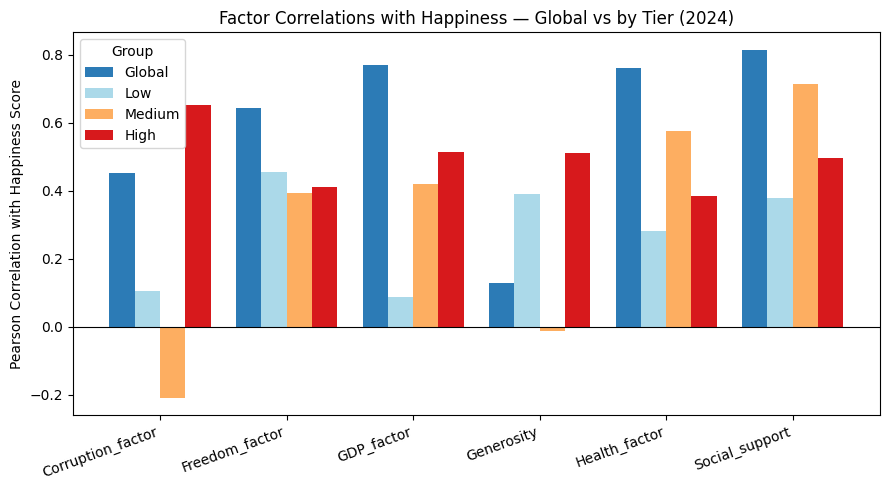

In [9]:
# e.g. df.plot(kind='bar'); plt.title('...')
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(result.index))
width = 0.2
colors = ['#2c7bb6','#abd9e9','#fdae61','#d7191c']

for i, (col, color) in enumerate(zip(result.columns, colors)):
    ax.bar(x + i * width, result[col], width, label=col, color=color)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(result.index, rotation=20, ha='right')
ax.set_ylabel('Pearson Correlation with Happiness Score')
ax.set_title('Factor Correlations with Happiness — Global vs by Tier (2024)')
ax.legend(title='Group')
ax.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

### Chart for Finding 2

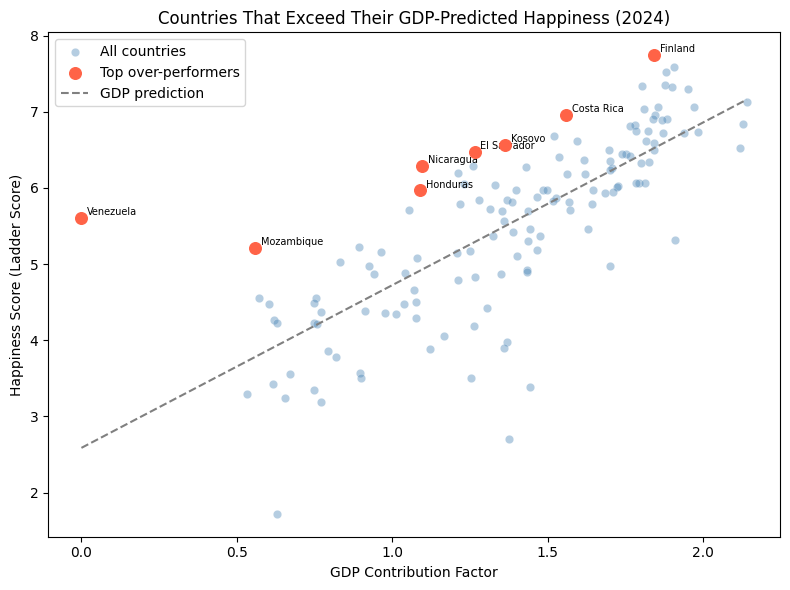

In [10]:
# e.g. df.plot(kind='bar'); plt.title('...')
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df['GDP_factor'], df['Ladder_score'], alpha=0.4, color='steelblue',
           edgecolors='white', linewidth=0.3, label='All countries')

# Highlight top over-performers
top_over = df.nlargest(8, 'residual')
ax.scatter(top_over['GDP_factor'], top_over['Ladder_score'],
           color='tomato', zorder=5, s=70, label='Top over-performers')
for _, row in top_over.iterrows():
    ax.annotate(row['Country_name'], (row['GDP_factor'], row['Ladder_score']),
                fontsize=7, xytext=(4, 2), textcoords='offset points')

x_line = np.linspace(df['GDP_factor'].min(), df['GDP_factor'].max(), 100)
ax.plot(x_line, m * x_line + b, color='gray', linewidth=1.5,
        linestyle='--', label='GDP prediction')
ax.set_xlabel('GDP Contribution Factor')
ax.set_ylabel('Happiness Score (Ladder Score)')
ax.set_title('Countries That Exceed Their GDP-Predicted Happiness (2024)')
ax.legend()
plt.tight_layout()
plt.show()

### Chart for Finding 3

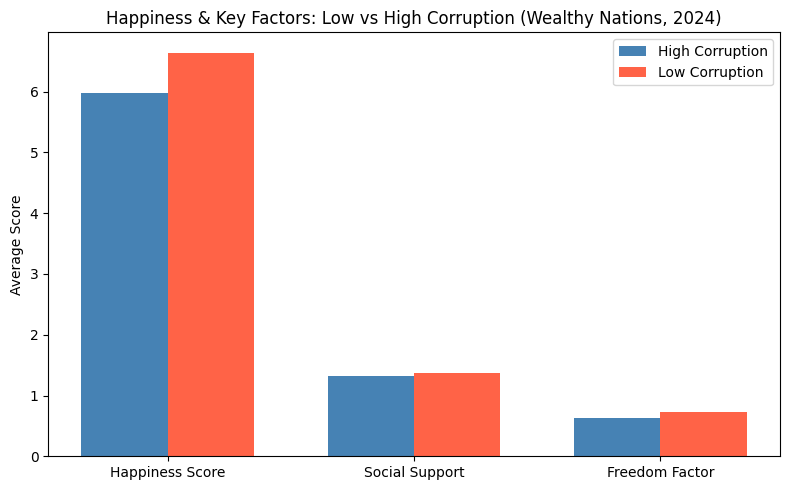

In [11]:
# e.g. df.plot(kind='bar'); plt.title('...')
import matplotlib.pyplot as plt
plot_data = wealthy.groupby('corruption_group')[
    ['Ladder_score','Social_support','Freedom_factor']
].mean().round(3)

x = np.arange(len(plot_data.columns))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))

for i, (group, color) in enumerate(zip(plot_data.index, ['steelblue','tomato'])):
    ax.bar(x + i * width, plot_data.loc[group], width, label=group, color=color)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(['Happiness Score','Social Support','Freedom Factor'])
ax.set_ylabel('Average Score')
ax.set_title('Happiness & Key Factors: Low vs High Corruption (Wealthy Nations, 2024)')
ax.legend()
plt.tight_layout()
plt.show()

#### Q4  Rubric – Visual Communication

The section requires **three** separate charts (one per finding).  
Each chart is worth **6 pts**, and 2 pts are reserved for code hygiene.

| For **each** chart | What we’re looking for | Pts |
|--------------------|-----------------------|-----|
| **Technical correctness** | Chart executes without error; chosen type matches the data | **2** |
| **Annotation quality** | Descriptive title **and** properly labelled axes (legend if needed) | **2** |
| **Clarity & alignment** | Readable layout (no label overlap, sensible scales) **and** the graphic clearly supports its finding | **2** |
| **Subtotal per chart** |   | **6 pts** |

**3 charts × 6 pts = 18 pts**

| Overall notebook | Criteria | Pts |
|------------------|----------|-----|
| **Code hygiene** | One chart per cell, consistent styling, tidy comments | **2 pts** |

| **Section total** |   | **20 pts** |



## Q5  Reproducibility & reflection 💯 (15 pts)

### 5a Sample SQL

Using SQL only, a technique to get a sample of the data.  This can be done any way you want.

You must describe what the SQL is doing and why that SQL logic is returning a sample (subset) of the data.

### 5 a  Sample SQL (basic proficiency)

The query filters to the top GDP quartile countries and groups them by `corruption_group`, returning the count of countries, average happiness score, and average social support per group. The `WHERE` clause subsets the data to wealthier nations only, and `GROUP BY` with `AVG()` and `COUNT(*)` produces a two-row summary that directly reproduces the numeric results cited in Finding 3.

In [12]:
# sql string goes here
import pandas as pd, sqlite3

sql = """
    SELECT corruption_group,
           COUNT(*)                         AS country_count,
           ROUND(AVG(Ladder_score), 3)      AS avg_happiness,
           ROUND(AVG(Social_support), 3)    AS avg_social_support,
           ROUND(AVG(Freedom_factor), 3)    AS avg_freedom
    FROM   happiness
    WHERE  gdp_quartile = 'Q4 (Highest)'
    GROUP  BY corruption_group
    ORDER  BY avg_happiness DESC
"""

con = sqlite3.connect('project.db')
sample_df = pd.read_sql(sql, con)
con.close()
sample_df

,corruption_group,country_count,avg_happiness,avg_social_support,avg_freedom
0,Low Corruption,31,6.821,1.413,0.729
1,High Corruption,4,6.508,1.377,0.591


In [13]:
import pandas as pd, sqlite3
con = sqlite3.connect('project.db')
# sample_df = pd.read_sql(sql string from prior code block, con)



### 5b Limitations / next steps

_In 2–3 sentences, discuss data limitations, assumptions, and future work._

The 2024 report omits roughly 50 nations, many in conflict zones or with limited statistical infrastructure, which skews global averages upward and makes bottom-tier findings less representative. A more fundamental limitation is that happiness scores are self-reported by citizens and reflect personal life satisfaction, not external assessments of a country's government or actions. A country can score highly even while its state engages in conduct widely condemned internationally, which means the index should not be interpreted as a measure of national virtue or humanitarian standing. Future work could incorporate external indicators, such as conflict intensity, press freedom, or income inequality (Gini coefficient), alongside the self-reported scores to surface countries where citizen-reported wellbeing diverges sharply from objective conditions on the ground.

### Q5 Rubric – SQL & Reflection

| Sub-task | Criteria | Pts |
|----------|----------|-----|
| **5 a  SQL query & result** | Query executes without error on `project.db` | **3** |
| | Uses **at least one** of: `WHERE`, `LIMIT`, `GROUP BY` + aggregate | **4** |
| | Result reproduced in a DataFrame | **3** |
| **Subtotal 5 a** |   | **10** |
| **5 b  Limitations & next steps** | Identifies ≥ 2 data limitations **and** ≥ 1 future improvement | **3** |
| | Clear, concise writing (≤ 150 words; no jargon) | **2** |
| **Subtotal 5 b** |   | **5** |
| **Section total** |   | **15 pts** |
